# SIMPLE LINEAR REGRESSION
* y=ax + b 
x= bağımsız değişken
y= bağımlı değişken
a = coefficient (katsayı)

* Linear, değişkenler arasındaki ilişkinin sabit bir oranda ilerlemesi demektir. Yani biri artarken diğeri de belli bir oranda artıyor veya azalıyor diyebiliyorsak bu bir doğrusaldır.

## ÖRNEK
* Sen ne kadar çok ekmek alırsan, ödeyeceğin para da o kadar doğrusal olarak artar.

## ÇİZGİNİN AMACI NEDİR?
* Modelin amacı, geçmiş verilere bakarak çizilen çizgide, gelecekte bir veri geldiğinde o çizgi üzerinden tahmin yapabilmektir.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [10]:
veriler = pd.read_csv('satislar.csv')
veriler.head()

,Aylar,Satislar
0,8,19671.5
1,10,23102.5
2,11,18865.5
3,13,21762.5
4,14,19945.5


In [11]:
from sklearn.model_selection import train_test_split
#Verimizdeki sütunları ayırdık
aylar = veriler[['Aylar']]
satislar = veriler[['Satislar']]


In [12]:
x_train,x_test,y_train,y_test = train_test_split (aylar,satislar,test_size=0.33,random_state=0)
#Parantez içinde birinci değer her zaman bağımsız değişken yazılır, bizim veri setimizde bu aylar.
#İkinci parametre ise bağımlı yani tahmin etmek istediğimiz değer.

In [13]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(x_train)
X_test = sc.transform(x_test)
Y_train =sc.fit_transform(y_train)
Y_test = sc.transform(y_test)

In [14]:
#Model inşası (Linear Regression)
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,Y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
tahmin=lr.predict(X_test)
tahmin
#X_test'i tahmin et diyoruz ve tahmin sonucunu tutuyoruz.



array([[-0.97441382],
       [ 1.7872938 ],
       [-0.19279846],
       [-0.24490615],
       [ 1.52675535],
       [ 1.26621689],
       [ 1.52675535],
       [-0.24490615],
       [ 0.22406307],
       [ 1.00567844]])

In [ ]:
lr.fit(x_train,y_train)
tahmin = lr.predict(x_test)


array([[20126.21865404],
       [57740.29412655],
       [30771.7117123 ],
       [30062.01217508],
       [54191.79644047],
       [50643.29875438],
       [54191.79644047],
       [30062.01217508],
       [36449.30801003],
       [47094.80106829]])

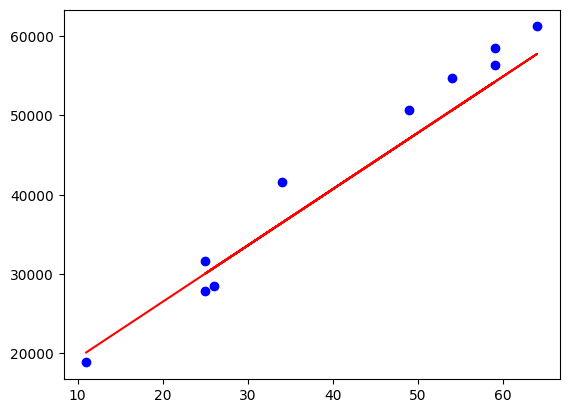

In [35]:
x_train = x_train.sort_index()
y_train = y_train.sort_index()
plt.plot(x_test,lr.predict(x_test),color='red')
plt.scatter(x_test,y_test,color='blue')